In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ratings = pd.read_csv(
    "Data/ml-100k/u.data",
    sep = "\t",
    names = ["userId", "movieId", "rating", "timestamp"]
)

# transformo u.data en algo mas leible y sectorizable
cols_item = ['movieId', 'title', 'release_date', 'video_release', 'imdb_url',
             'unknown','Action','Adventure','Animation','Children','Comedy',
             'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
             'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']

movies  = pd.read_csv(
    "Data/ml-100k/u.item",
    sep = "|",
    names = cols_item,
    encoding = "latin-1",
    usecols = range(24)
)

#chequeo que todo haya quedado bien cargado
print(ratings.head())
print(movies.head())
print(ratings.shape)
print(movies.shape)


   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
   movieId              title release_date  video_release  \
0        1   Toy Story (1995)  01-Jan-1995            NaN   
1        2   GoldenEye (1995)  01-Jan-1995            NaN   
2        3  Four Rooms (1995)  01-Jan-1995            NaN   
3        4  Get Shorty (1995)  01-Jan-1995            NaN   
4        5     Copycat (1995)  01-Jan-1995            NaN   

                                            imdb_url  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0       0   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...        0       1   
4  http://us.imdb.com/M/title-exact?Copy

Estadisticas Básicas

In [2]:
print(f"Usuarios únicos:  {ratings['userId'].nunique()}")
print(f"Películas únicas: {ratings['movieId'].nunique()}")
print(f"Total de ratings: {len(ratings)}")
print(f"\nRating promedio: {ratings['rating'].mean():.2f}")
print(f"Ratings por usuario (promedio): {ratings.groupby('userId')['rating'].count().mean():.1f}")

Usuarios únicos:  943
Películas únicas: 1682
Total de ratings: 100000

Rating promedio: 3.53
Ratings por usuario (promedio): 106.0


Distribución de Ratings

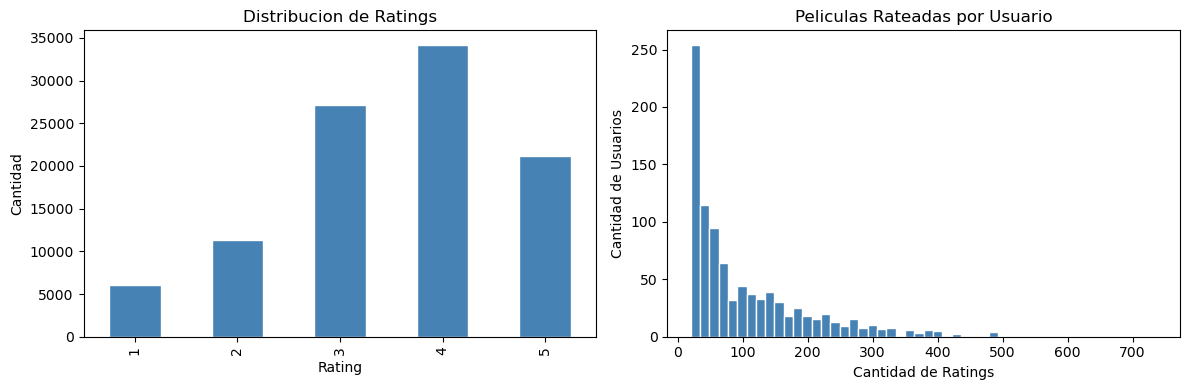

In [3]:
fig, axes = plt.subplots(1,2,figsize = (12,4))

#distribucion de puntajes
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],color='steelblue',edgecolor='white'
)
axes[0].set_title('Distribucion de Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Cantidad')

#cantidad de peliclas que rateo cada usuario
ratings_por_usuario = ratings.groupby('userId')['rating'].count()
axes[1].hist(ratings_por_usuario,bins=50,color='steelblue',edgecolor='white')
axes[1].set_title('Peliculas Rateadas por Usuario')
axes[1].set_xlabel('Cantidad de Ratings')
axes[1].set_ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

Sparsity (Matriz Dispersa)

movieId  1     2     3     4     5     6     7     8     9     10    ...  \
userId                                                               ...   
1         5.0   3.0   4.0   3.0   3.0   5.0   4.0   1.0   5.0   3.0  ...   
2         4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   2.0  ...   
3         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
5         4.0   3.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
...       ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
939       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   5.0   NaN  ...   
940       NaN   NaN   NaN   2.0   NaN   NaN   4.0   5.0   3.0   NaN  ...   
941       5.0   NaN   NaN   NaN   NaN   NaN   4.0   NaN   NaN   NaN  ...   
942       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
943       NaN   5.0   NaN   NaN   NaN   NaN   NaN   NaN   3.0   NaN  ...   

movieId  16

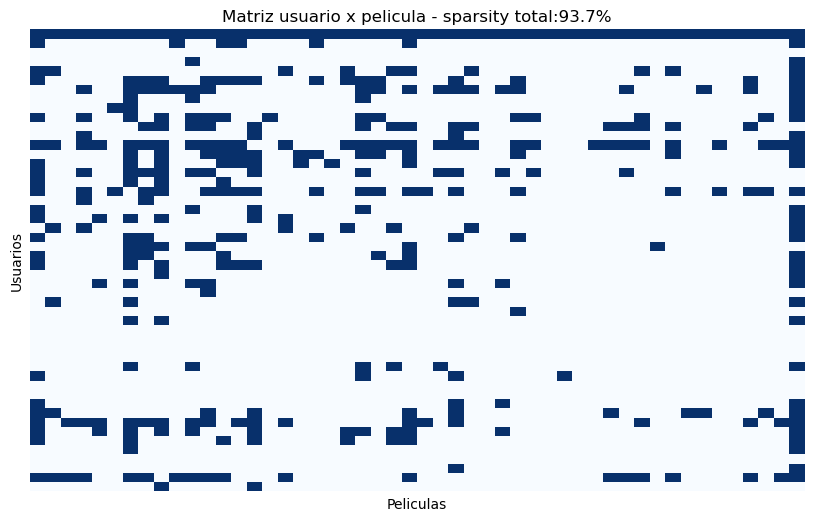

0


In [4]:
#armo la matriz usuario x pelicula
matriz = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

#visualizo la matriz para chequear que este bien definida
print(matriz)

#calculo sparsity
total_celdas = matriz.shape[0] * matriz.shape[1] #la matriz no tiene porque ser cuadrada
celdas_con_dato = ratings.shape[0]
sparsity = 1 - (celdas_con_dato/ total_celdas)

print(f"Tamaño de la matriz: {matriz.shape}")
print(f"Sparsity: {sparsity:.2%}")

#visualizamos una parte
plt.figure(figsize=(10,6))
sns.heatmap(
    matriz.iloc[:50,:50].notna(),
    cmap='Blues',
    cbar=False,
    xticklabels=False,
    yticklabels=False
)
plt.title(f'Matriz usuario x pelicula - sparsity total:{sparsity:.1%}')
plt.xlabel('Peliculas')
plt.ylabel('Usuarios')
plt.show()

#calculo promedios por usuario
user_means = matriz.mean(axis=1)

#armo la matriz sin los 0's
matriz_final = matriz.copy()
for user in matriz.index:
    mean_rating = matriz.loc[user].mean()
    matriz_final.loc[user] = matriz.loc[user].fillna(mean_rating)
    
#chequeamos (tiene q dar 0)
print(matriz_final.isna().sum().sum())

Como se puede ver, mayoritariamente la matriz tiene valores vacios, por lo que va a ser dificil interconectar usuarios para poder predecir sus gustos debido a que puede pasar que no haya solapamiento entre sus ratings. Para esto, vamos a utilizar la SVD, para poder descomponer la matriz y utilizar los datos que nos interesan para predecir.
La descomposicion de la matriz M será:
$$ \mathbf{M}_{m \times n} \approx \mathbf{U}_{m \times k} \cdot \mathbf{\Sigma}_{k \times k} \cdot \mathbf{V}^T_{k \times n} $$

donde $m$ es la cantidad de usuarios, $n$ la cantidad de peliculas y $k$ el factor de compresion.

La importancia de $k$ es que nos permite achicar el problema, puesto que tenemos una matriz de 943x1682, al fijar un valor de $k$ lo que hacemos es manejar el ruido que van a tener nuestros datos. Valores altos de $k$ van a dificultar la prediccion de gustos nuevos y valores bajos de $k$ van a hacer que se le recomiende a todos los usuarios lo mismo. En este caso, trabajaremos con $k \in \{20, \dots, 100\}$ que es el punto perfecto, lo que nos permitira agrupar la informacion en $k$ categorias abstractas, sin perder precisión y veracidad a la hora de recomendar.

Descomposición en Valores Singulares

In [5]:
from scipy.sparse.linalg import svds

M = matriz_final.values

#vamos a usar svds en lugar de svd ya que tenemos una matriz dispersa y es mas eficiente que usar np.linalg.svd
k = 50
U,sigma,Vt = svds(M,k=k)

#me devuelven sigma como vector, asi que uso np.diag para armar una matriz diagonal con cada elemento del vector en las diagonales => sigma_ii = sigma[i]
sigma_diag = np.diag(sigma)

#chequeamos que todo este bien
print(f"Tamaño de U: {U.shape}")
print(f"Tamaño de Sigma : {sigma_diag.shape}")
print(f"Tamaño de Vt: {Vt.shape}")


Tamaño de U: (943, 50)
Tamaño de Sigma : (50, 50)
Tamaño de Vt: (50, 1682)


En la matriz de Usuarios $U$ almacenamos la afinidad de cada usuario con cada factor de compresión.
 
En la matriz $\Sigma$ almacenamos la importancia de cada factor de compresión. 

En la matriz de Películas $V^T$ almacenamos el perfil de cada película en relación con los factores de compresión.


In [6]:
#voy a conseguir mi matriz M que aproxime fijando el valor de k
M_aprox= U @ sigma_diag @ Vt 

#lo hago dataframe con pandas para poder hacerle un seguimiento a las peliculas y los usuarios con su respectivo Id
matriz_aprox = pd.DataFrame(
    M_aprox,
    index = matriz_final.index, #userId
    columns = matriz_final.columns #movieId
)
print("Matriz aproximada:")
print(matriz_aprox.shape) #chequeo dimensiones
print(matriz_aprox.iloc[:3, :5]) #chequeo estilo

Matriz aproximada:
(943, 1682)
movieId         1         2         3         4         5
userId                                                   
1        5.453643  3.599803  4.095666  3.287981  3.171682
2        3.799084  3.633264  3.617280  3.788801  3.669430
3        2.784616  2.736302  2.950265  2.714215  2.723298


In [7]:
def recomendar_colaborativo(userId, n=10):
    """
    Dado un userId, devuelve las n películas más recomendadas
    que el usuario todavía no vio
    """
    # pelis que el usuario ya vio
    peliculas_vistas = matriz.loc[userId].dropna().index.tolist()

    # todos los ratings predichos para este usuario
    ratings_predichos= matriz_aprox.loc[userId]

    # filtro las que ya vio y las ordeno por score predicho
    recomendaciones = (
    ratings_predichos
    .drop(index=peliculas_vistas) # elimino las que ya vio
    .sort_values(ascending=False) # las ordeno decrecientemente
    .head(n)                      # top n
    )
    
    # agrego el titulo de cada peli
    resultado = pd.DataFrame({
        'movieId': recomendaciones.index,
        'score_predicho': recomendaciones.values
    })
    resultado = resultado.merge(
        movies[['movieId','title']],
        on='movieId'
    )
    
    return resultado[['title','score_predicho']]

#chequeo resultado con user1
print(recomendar_colaborativo(userId=1))

                                               title  score_predicho
0                            Schindler's List (1993)        4.608927
1             One Flew Over the Cuckoo's Nest (1975)        4.362459
2                   In the Name of the Father (1993)        4.339729
3                  Jackie Chan's First Strike (1996)        4.327895
4                              Secrets & Lies (1996)        4.312636
5                           Conspiracy Theory (1997)        4.311386
6                          Lawrence of Arabia (1962)        4.278596
7                                 Bob Roberts (1992)        4.220003
8  Like Water For Chocolate (Como agua para choco...        4.213206
9                              Ice Storm, The (1997)        4.209088


Ahora, para medir que tan efectivas son las predicciones, vamos a hacer uso del RMSE; vamos a agarrar ratings reales ya existentes, vamos a probar a predecirlos sin verlos y ahi, medimos el error para poder chequear que pasa. La formula del RMSE, que deriva directamente del MSE, ambas directamente conectadas a LSM que es un metodo para hallar aproximaciones y medir errores.

**Mean Squared Error (MSE)**
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Descripción:**  
El MSE mide el error promedio entre los valores reales $y_i$ y las predicciones $\hat{y}_i$, penalizando más los errores grandes al elevarlos al cuadrado.

**Root Mean Squared Error (RMSE)**
$$
RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

**Descripción:**  
El RMSE es la raíz cuadrada del MSE, lo que permite interpretar el error en la misma escala que los datos originales.

En este caso, para mi modelo uso el RMSE porque me permite interpretar los resultados más fácilmente, ya que los valores que devuelve están en las unidades originales (ratings), mientras que el MSE está en unidades al cuadrado.
En particular, si MSE = 1, esto significa que el error cuadrático promedio es 1. Para interpretarlo en términos de error típico, se utiliza el RMSE:
$$
RMSE = \sqrt{MSE}
$$
Por lo tanto, si MSE = 1, entonces RMSE = 1, lo que implica que, en promedio, el modelo se equivoca en aproximadamente 1 unidad de rating.

Esto hace que el RMSE sea más interpretable y útil para evaluar el desempeño del modelo en este contexto específico

In [8]:
from sklearn.metrics import mean_squared_error

# aplano la matriz original en pares (userId,movieId,rating_real)
ratings_reales=(
    matriz.stack() #convierte la matriz a series con indice (userId,movieId)
    .reset_index()
    .rename(columns={0:'rating_real'})
)

# aplano la matriz predicha igualmente
ratings_pred = (
    matriz_aprox.stack()
    .reset_index()
    .rename(columns={0:'rating_predicho'})
)

comparacion = ratings_reales.merge(ratings_pred,on=['userId','movieId'])

# calculo el MSE
mse = mean_squared_error(
    comparacion['rating_real'],
    comparacion['rating_predicho']
)
rmse=np.sqrt(mse)

# chequeamos
print(f"RMSE del modelo colaborativo (k={k}): {rmse:.4f}")

RMSE del modelo colaborativo (k=50): 0.7280


En este caso, se obtuvo:

$$
RMSE \approx 0.728
$$

Este valor indica que, en promedio, el modelo comete un error de aproximadamente 0.73 puntos de rating, lo cual representa un buen ajuste sobre los datos observados.

Sin embargo, es importante interpretar correctamente este resultado. La matriz aproximada se obtiene mediante una factorización SVD truncada:

$$
M \approx M_k = U_k \Sigma_k V_k^T
$$

Desde el punto de vista teórico, esta aproximación resuelve el siguiente problema de optimización:

$$
\min_{\operatorname{rank}(X) \le k} |M - X|_F^2
$$

donde $|\cdot|_F$ es la norma de Frobenius:

$$
|M - M_k|F^2 = \sum{i,j} (M_{ij} - (M_k)_{ij})^2
$$

Esto implica que el modelo está optimizado explícitamente para minimizar el error cuadrático sobre la misma matriz utilizada en el entrenamiento. Por lo tanto, el RMSE calculado mide la calidad de reconstrucción de la matriz original, y no la capacidad de predicción sobre datos no observados.

En consecuencia, el valor obtenido debe interpretarse como una medida de qué tan bien el modelo logra aproximar la estructura de los datos existentes.

Experimentacion variando $k$

In [9]:
resultados_k = []
for k_test in [10,20,50,100,200]:
    U_t, sigma_t, Vt_t = svds(M,k=k_test)
    sigma_diag_t = np.diag(sigma_t)
    M_aprox_t = U_t @ sigma_diag_t @ Vt_t
    
    pred_vals = M_aprox_t[
        matriz.stack().index.get_level_values(0) - 1, # indice del user
        matriz.stack().index.get_level_values(1) - 1  # indice de la peli
    ]
    
    mse_t = mean_squared_error(
        ratings_reales['rating_real'],
        pred_vals
    )
    
    rmse_t=np.sqrt(mse_t)
    
    resultados_k.append({'k':k_test,'RMSE':round(rmse_t,4)})

df_k = pd.DataFrame(resultados_k)
print(df_k)

     k    RMSE
0   10  0.9074
1   20  0.8530
2   50  0.7280
3  100  0.5760
4  200  0.3702


Recordemos que $k$ controla el rango de la matriz aproximada:

$$
M_k = U_k \Sigma_k V_k^T
$$

A medida que aumenta $k$:

Se incorporan más factores de compresión.
La aproximación se vuelve más precisa.
El error de reconstrucción disminuye.

Desde el punto de vista teórico, se cumple que:

$$
\|M - M_k\|_F^2 = \sum\limits_{i=k+1}^{r} \sigma_i^2
$$

donde:

$M \in \mathbb{R}^{m \times n}$ es la matriz original de ratings

$M_k$ es la aproximación de rango $k$ obtenida mediante SVD truncada.

$|\cdot|_F$ denota la norma de Frobenius, que mide el error cuadrático total entre ambas matrices.

$\sigma_i$ son los valores singulares de $ M $, ordenados de mayor a menor, $ \sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r $.

$r = \operatorname{rg}(M)$ es el rango de la matriz original.

La suma $\sum_{i=k+1}^{r} \sigma_i^2 $ representa la información que se pierde al truncar la descomposición en los primeros $k$ componentes.

Esta expresión muestra que el error de reconstrucción depende únicamente de los valores singulares descartados, lo que explica por qué al aumentar $ k $ el error disminuye.

Sin embargo, dado que el RMSE se está calculando sobre los mismos datos utilizados para construir la matriz, esta disminución refleja únicamente una mejora en la capacidad de reconstrucción del modelo.

En un escenario de evaluación más realista (con separación entre entrenamiento y prueba), se esperaría observar un comportamiento distinto:

Para valores pequeños de $k$: el modelo subajusta (underfitting).

Para valores grandes de $k$: el modelo puede sobreajustar (overfitting).

Existe un valor óptimo de $k$ que minimiza el error en datos no vistos.

En este trabajo, el análisis de RMSE al variar $k$ permite comprender cómo la cantidad de factores de compresión influye en la calidad de la aproximación, aunque no constituye una validación completa del poder predictivo del modelo.

$k$ vs RMSE

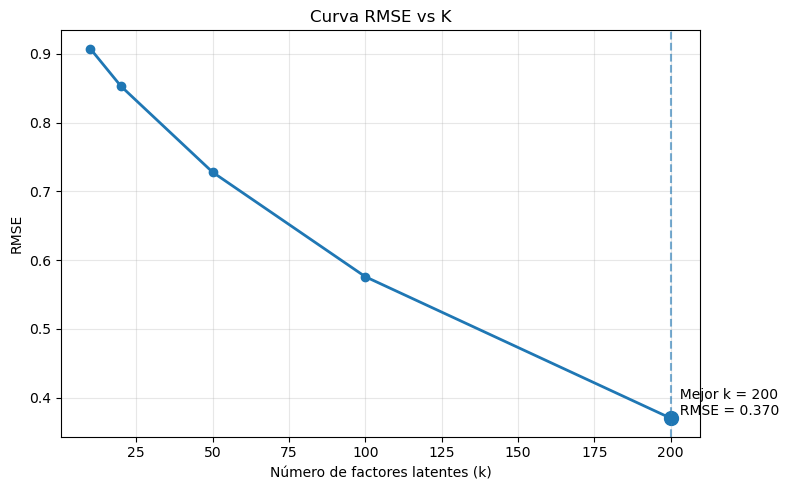

In [10]:
df_k = df_k.sort_values('k')

x = df_k['k']
y = df_k['RMSE']

best_row = df_k.loc[df_k['RMSE'].idxmin()]
best_k = best_row['k']
best_rmse = best_row['RMSE']

plt.figure(figsize=(8,5))


plt.plot(x, y, marker='o', linewidth=2)

plt.scatter(best_k, best_rmse, s=100)
plt.axvline(best_k, linestyle='--', alpha=0.6)

plt.text(best_k, best_rmse,
         f'  Mejor k = {int(best_k)}\n  RMSE = {best_rmse:.3f}',
         verticalalignment='bottom')

plt.xlabel('Número de factores latentes (k)')
plt.ylabel('RMSE')
plt.title('Curva RMSE vs K')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Filtrado Por Contenido

In [11]:
# creo los vectores con los generos

genre_cols = ['unknown','Action','Adventure','Animation','Children',
              'Comedy','Crime','Documentary','Drama','Fantasy',
              'Film-Noir','Horror','Musical','Mystery','Romance',
              'Sci-Fi','Thriller','War','Western']

# Matriz de Generos: cada fila va a ser una pelicula y cada columna un genero
genre_matrix = movies.set_index('movieId')[genre_cols].values 

print(f"Forma de la matriz de generos: {genre_matrix.shape}")
print(f"Ejemplo - Toy Story (movieId=1): {genre_matrix[0]}")

Forma de la matriz de generos: (1682, 19)
Ejemplo - Toy Story (movieId=1): [0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


Para medir la similitud entre películas, representamos cada película
como un vector binario de géneros en $\mathbb{R}^{19}$, donde cada
componente indica si la película pertenece o no a ese género.

La similitud entre dos películas $A$ y $B$ se mide con el coseno
del ángulo entre sus vectores:

$$\text{similitud}(A,B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

Un valor cercano a 1 indica géneros casi idénticos.
Un valor cercano a 0 indica que no comparten ningún género.

In [12]:
from sklearn.metrics.pairwise import cosine_similarity
# calculo la similitud coseno
similitud_contenido = cosine_similarity(genre_matrix)

# Lo convierto a un df para poder usar movieId como indice
similitud_df = pd.DataFrame(
    similitud_contenido,
    index = movies['movieId'].values,
    columns = movies['movieId'].values
)

print(f"Forma de la matriz de similitud: {similitud_df.shape}")
print(f"\nSimilitud de Toy Story con las primeras 5 películas:")
print(similitud_df.loc[1].head())

Forma de la matriz de similitud: (1682, 1682)

Similitud de Toy Story con las primeras 5 películas:
1    1.000000
2    0.000000
3    0.000000
4    0.333333
5    0.000000
Name: 1, dtype: float64


In [13]:
# creo la funcion de recomendacion x contenido
def recomendar_contenido(movieId,n=10):
    """
    Dada una pelicula, devuelve las n mas similares por genero
    """
    if movieId not in similitud_df.index:
        print(f"movieId {movieId} no encontrado")
        return None
    similitudes = similitud_df.loc[movieId]
    
    recomendaciones = (
        similitudes
        .drop(index=movieId)        # excluyo la pelicula misma
        .sort_values(ascending=False)       # las mas similares primero
        .head(n)
    )
    
    resultado = pd.DataFrame({
        'movieId': recomendaciones.index,
        'similitud': recomendaciones.values
    })
    resultado = resultado.merge(movies[['movieId', 'title']], on='movieId')

    return resultado[['title', 'similitud']]

# busco qué es similar a toy story usando la similitud coseno :)
print("Películas similares a Toy Story (1995):")
print(recomendar_contenido(movieId=1))

Películas similares a Toy Story (1995):
                                         title  similitud
0       Aladdin and the King of Thieves (1996)   1.000000
1                        Goofy Movie, A (1995)   0.866025
2                               Aladdin (1992)   0.866025
3                            Home Alone (1990)   0.816497
4                      Flintstones, The (1994)   0.816497
5                   Little Rascals, The (1994)   0.816497
6  Winnie the Pooh and the Blustery Day (1968)   0.816497
7                          Home Alone 3 (1997)   0.816497
8                       Aristocats, The (1970)   0.816497
9                        Big Green, The (1995)   0.816497


Vemos que las peliculas que recomienda la funcion, son racionales puesto que toy story esta clasificado como animation + children + comedy, y las peliculas que nos devuelve, en el caso de la primera, esta rateada igual que toy story, y en el resto, comparte generos.

Fusionar todo en el Modelo Híbrido

Como se ve arriba, el modelo de contenido funciona. Ahora lo que surge es que hay que ver como combinar el score colaborativo que nos brinda el uso de la SVD; que es un rating predicho entre 1 y 5 y que a grandes rasgos funciona bajo la lógica de "segun usuarios parecidos a vos, esta pelicula te gustaria X", siendo X el rating que devuelve la SVD, y el score de contenido, que es lo que voy a programar ahora, que se rige de la siguiente manera; para cada pelicula no vista, veo que tan parecida es a las peliculas que el usuario ya vio y le gustarion.
Si el usuario vio Toy Story y le agradó, y tenemos a la pelicula Winnie Pooh sin ser vista, si Winnie Pooh tiene generos parecidos a los de Toy Story (o una similitud coseno alta), se le recomendará al usuario esa pelicula.

En este contexto, hay una problemática; ambos scores estan en escalas distintas. Mientras que usando SVD conseguimos un entero del 1 al 5, usando similitud coseno recibimos un float entre 0 y 1. Voy a normalizar para llevar ambos scores a la misma escala [0, 1].

In [14]:
# funcion para calcular el score de contenido por usuario
def calcular_score_contenido(userId,peliculas_no_vistas):
    """
    Para un usuario dado, calcula el puntaje de contenido para cada
    película que todavía no vio.

    La idea es: para cada película no vista, calculamos cuánto se
    parece a las películas que el usuario SÍ vio, ponderando por el
    rating que les dio. Si amó (5 estrellas) una película muy similar,
    el score va a ser alto.
    """
    
    peliculas_vistas = matriz.loc[userId].dropna()
    
    scores = {}
    for movieId in peliculas_no_vistas:
        similitudes = similitud_df.loc[movieId,peliculas_vistas.index]
        
        # promedio ponderado: similitud * rating / sumatoria de ratings
        score = np.dot(similitudes.values,peliculas_vistas.values) / (peliculas_vistas.values.sum() + 1e-8)
        scores[movieId] = score 
        
    return pd.Series(scores)

# Probamos para el usuario 1
peliculas_vistas_u1 = matriz.loc[1].dropna().index.tolist()
peliculas_no_vistas_u1 = [m for m in matriz.columns if m not in peliculas_vistas_u1]

score_cont_u1 = calcular_score_contenido(1, peliculas_no_vistas_u1)
print(f"Score de contenido calculado para {len(score_cont_u1)} películas")
print(f"Rango: {score_cont_u1.min():.3f} - {score_cont_u1.max():.3f}")

Score de contenido calculado para 1410 películas
Rango: 0.004 - 0.405


In [15]:
# funcion de recomendacion hibrida
def recomendar_hibrido(userId, a=0.7,n=10):
    """
    Sistema de recomendación híbrido.

    Parámetros:
    - userId: el usuario al que le queremos recomendar
    - alpha: peso del modelo colaborativo (entre 0 y 1)
             alpha=1.0 → solo colaborativo
             alpha=0.0 → solo contenido
             alpha=0.7 → 70% colaborativo, 30% contenido
    - n: cantidad de recomendaciones a devolver
    """

    peliculas_vistas = matriz.loc[userId].dropna().index.tolist()
    peliculas_no_vistas = [m for m in matriz.columns if m not in peliculas_vistas]

    # --- score colaborativo (SVD) ---
    score_colab = matriz_aprox.loc[userId, peliculas_no_vistas]

    # --- score de contenido ---
    score_cont = calcular_score_contenido(userId, peliculas_no_vistas)

    # --- normalizamos ambos a escala [0, 1] ---
    score_colab_norm = (score_colab - score_colab.min()) / (score_colab.max() - score_colab.min())
    score_cont_norm  = (score_cont  - score_cont.min())  / (score_cont.max()  - score_cont.min())

    # --- combinamos con el parámetro alpha (a) ---
    score_final = a * score_colab_norm + (1 - a) * score_cont_norm

    # --- top N películas con mayor score ---
    top_n = score_final.sort_values(ascending=False).head(n)

    resultado = pd.DataFrame({
        'movieId': top_n.index,
        'score_final': top_n.values
    })
    resultado = resultado.merge(movies[['movieId', 'title']], on='movieId')

    return resultado[['title', 'score_final']]

# Probamos con el usuario 1 y alpha=0.7
print("Recomendaciones híbridas para el usuario 1 (alpha=0.7):")
print(recomendar_hibrido(userId=1, a=0.7))

Recomendaciones híbridas para el usuario 1 (alpha=0.7):
                                               title  score_final
0                            Schindler's List (1993)     0.902166
1             One Flew Over the Cuckoo's Nest (1975)     0.862131
2                   In the Name of the Father (1993)     0.854312
3                              Secrets & Lies (1996)     0.844992
4       Rosencrantz and Guildenstern Are Dead (1990)     0.826999
5                              Night on Earth (1991)     0.819529
6                              Ice Storm, The (1997)     0.809372
7  Like Water For Chocolate (Como agua para choco...     0.796346
8                             Beautiful Girls (1996)     0.794575
9      William Shakespeare's Romeo and Juliet (1996)     0.788445


Comparación entre los 3 enfoques

In [16]:
userId_prueba = 1

print("=" * 55)
print(f"Recomendaciones para usuario {userId_prueba}")
print("=" * 55)

print("\n[Solo colaborativo (SVD)]")
print(recomendar_colaborativo(userId=userId_prueba).to_string(index=False))

print("\n[Solo contenido]")
print(recomendar_hibrido(userId=userId_prueba, a=0.0).to_string(index=False))

print("\n[Híbrido 70% colaborativo / 30% contenido]")
print(recomendar_hibrido(userId=userId_prueba, a=0.7).to_string(index=False))

Recomendaciones para usuario 1

[Solo colaborativo (SVD)]
                                                     title  score_predicho
                                   Schindler's List (1993)        4.608927
                    One Flew Over the Cuckoo's Nest (1975)        4.362459
                          In the Name of the Father (1993)        4.339729
                         Jackie Chan's First Strike (1996)        4.327895
                                     Secrets & Lies (1996)        4.312636
                                  Conspiracy Theory (1997)        4.311386
                                 Lawrence of Arabia (1962)        4.278596
                                        Bob Roberts (1992)        4.220003
Like Water For Chocolate (Como agua para chocolate) (1992)        4.213206
                                     Ice Storm, The (1997)        4.209088

[Solo contenido]
                          title  score_final
           Reality Bites (1994)          1.0
         

Saquemos algunas conclusiones........

-) El modelo colaborativo tiene sentido; la SVD encontro usuarios con gustos similares al usuario 1 y recomendó lo que a ellos les encantó.

-) El modelo de contenido solo, devuelve todo con score 1.0 puesto que el usuario 1 vio muuuuchas peliculas de Drama y Comedia por lo que al normalizar, todas las peliculas no vistas que son Drama/Comedia puro, empatan en el máximo. La funcion se ve que devuelve las primeras 10 de ese empate.

-) El modelo híbrido pone en juego, peliculas que no estaban en el colaborativo, esas peliculas son de drama independiente, que matchean con el perfil de contenido del usuario. Se podria decir que el modelo hibrido aporta diversidad real.

Una pregunta que podría surgir ahora es: ¿Cual es la mejor configuracion para la funcion, es decir, cual es el valor óptimo de alpha?

Para responder esto, vamos a hacer un analisis variando alpha, y nos quedaremos con el que tenga mejores outputs y mas verosímiles. Para esto, separo los datos en entrenamiento y prueba antes de entrenar.

Train/Test split

In [17]:
from sklearn.model_selection import train_test_split

ratings_train, ratings_test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print(f"Ratings de entrenamiento: {len(ratings_train)}")
print(f"Ratings de prueba:        {len(ratings_test)}")

Ratings de entrenamiento: 80000
Ratings de prueba:        20000


In [18]:
# reconstruyola matriz usando solo los datos de entrenamiento
# los ratings de prueba se van a "predecir"; el modelo no los vio
matriz_train = ratings_train.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

matriz_train_final = matriz_train.apply(
    lambda row: row.fillna(row.mean()), axis=1
)

# aplico SVD con k=50 (como antes)
from scipy.sparse.linalg import svds

M_train = matriz_train_final.values
U_tr, sigma_tr, Vt_tr = svds(M_train, k=50)
sigma_diag_tr = np.diag(sigma_tr)

M_pred_train = U_tr @ sigma_diag_tr @ Vt_tr

matriz_pred_train = pd.DataFrame(
    M_pred_train,
    index=matriz_train_final.index,
    columns=matriz_train_final.columns
)

print("Modelo reentrenado con datos de entrenamiento ✓")

Modelo reentrenado con datos de entrenamiento ✓


Evaluar los alphas con un RMSE honesto

In [19]:

def precomputar_scores(ratings_test, matriz_pred, similitud_df, matriz_train):

    resultados = []

    for userId in ratings_test['userId'].unique():

        if userId not in matriz_pred.index:
            continue

        # películas que este usuario vio en entrenamiento
        peliculas_vistas = matriz_train.loc[userId].dropna()
        if len(peliculas_vistas) == 0:
            continue

        # ratings de prueba solo de este usuario
        test_usuario = ratings_test[ratings_test['userId'] == userId]

        scores_colab = matriz_pred.loc[userId]

        # ── score de contenido vectorizado ──

        cols_vistas = [c for c in similitud_df.columns if c in peliculas_vistas.index]
        ratings_vistos = peliculas_vistas[cols_vistas].values          # shape: (n_vistas,)
        sims_matrix = similitud_df[cols_vistas].values                 # shape: (1682, n_vistas)

        scores_cont_todos = sims_matrix @ ratings_vistos / (ratings_vistos.sum() + 1e-8)
        scores_cont = pd.Series(scores_cont_todos, index=similitud_df.index)

        # ── normalizamos por usuario ──
        colab_min, colab_max = scores_colab.min(), scores_colab.max()
        cont_min,  cont_max  = scores_cont.min(),  scores_cont.max()

        for _, row in test_usuario.iterrows():
            movieId    = row['movieId']
            rating_real = row['rating']

            if movieId not in scores_colab.index or movieId not in scores_cont.index:
                continue

            sc_norm = (scores_colab[movieId] - colab_min) / (colab_max - colab_min + 1e-8)
            cont_norm = (scores_cont[movieId] - cont_min)  / (cont_max  - cont_min  + 1e-8)

            resultados.append({
                'rating_real':      rating_real,
                'score_colab_norm': sc_norm,
                'score_cont_norm':  cont_norm
            })

    return pd.DataFrame(resultados)

print("Precomputando scores (tarda ~1 minuto)...")
df_scores = precomputar_scores(ratings_test, matriz_pred_train, similitud_df, matriz_train)
print(f"Listo: {len(df_scores)} ratings de prueba procesados ✓")

def evaluar_alpha(alpha, df_scores):
    score_final = alpha * df_scores['score_colab_norm'] + (1 - alpha) * df_scores['score_cont_norm']
    rating_pred = 1 + score_final * 4   # reescalamos a [1, 5]
    errores = (df_scores['rating_real'] - rating_pred) ** 2
    return np.sqrt(errores.mean())

print("Buscando el mejor alpha...\n")
resultados_alpha = []

for alpha in np.arange(0.0, 1.1, 0.1):
    rmse = evaluar_alpha(alpha, df_scores)
    resultados_alpha.append({'alpha': round(alpha, 1), 'RMSE': round(rmse, 4)})
    print(f"alpha = {alpha:.1f}  →  RMSE = {rmse:.4f}")

df_alpha = pd.DataFrame(resultados_alpha)

Precomputando scores (tarda ~1 minuto)...
Listo: 19969 ratings de prueba procesados ✓
Buscando el mejor alpha...

alpha = 0.0  →  RMSE = 1.4358
alpha = 0.1  →  RMSE = 1.3737
alpha = 0.2  →  RMSE = 1.3190
alpha = 0.3  →  RMSE = 1.2727
alpha = 0.4  →  RMSE = 1.2357
alpha = 0.5  →  RMSE = 1.2089
alpha = 0.6  →  RMSE = 1.1929
alpha = 0.7  →  RMSE = 1.1882
alpha = 0.8  →  RMSE = 1.1949
alpha = 0.9  →  RMSE = 1.2129
alpha = 1.0  →  RMSE = 1.2416


Visualizacion y Eleccion del Mejor Alpha

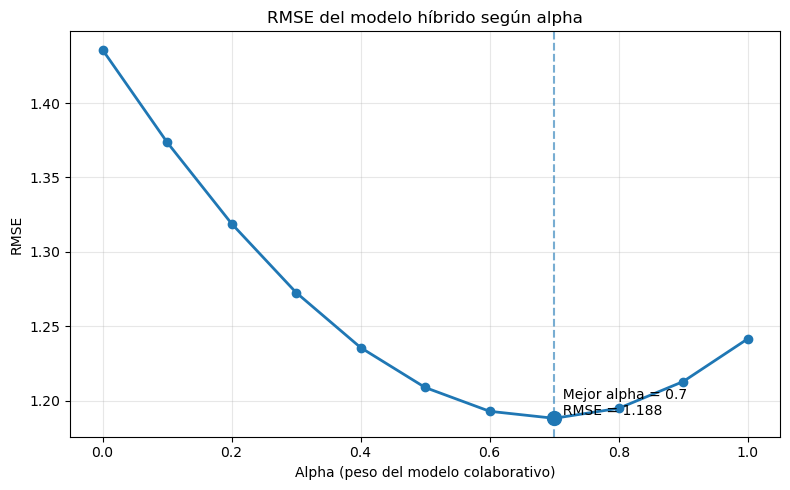


Mejor alpha: 0.7
RMSE mínimo: 1.1882


In [20]:
mejor = df_alpha.loc[df_alpha['RMSE'].idxmin()]

plt.figure(figsize=(8, 5))
plt.plot(df_alpha['alpha'], df_alpha['RMSE'], marker='o', linewidth=2)
plt.scatter(mejor['alpha'], mejor['RMSE'], s=100, zorder=5)
plt.axvline(mejor['alpha'], linestyle='--', alpha=0.6)
plt.text(
    mejor['alpha'], mejor['RMSE'],
    f"  Mejor alpha = {mejor['alpha']}\n  RMSE = {mejor['RMSE']:.3f}",
    verticalalignment='bottom'
)
plt.xlabel('Alpha (peso del modelo colaborativo)')
plt.ylabel('RMSE')
plt.title('RMSE del modelo híbrido según alpha')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMejor alpha: {mejor['alpha']}")
print(f"RMSE mínimo: {mejor['RMSE']:.4f}")

## 🔀 Evaluación del modelo híbrido

Se evaluó el modelo híbrido combinando el enfoque colaborativo (SVD) y el basado en contenido mediante un parámetro $\alpha$, definido como:

$$
\hat{r}*{ui} = \alpha \cdot \hat{r}*{ui}^{\text{colaborativo}} + (1 - \alpha) \cdot \hat{r}_{ui}^{\text{contenido}}
$$

donde:

* $\hat{r}_{ui}$ es el rating predicho final
* $\hat{r}_{ui}^{\text{colaborativo}}$ proviene de la factorización SVD
* $\hat{r}_{ui}^{\text{contenido}}$ se basa en similitud entre ítems
* $\alpha \in [0,1]$ controla el peso de cada componente

### 📊 Resultados

Se obtuvo:

* **Mejor $\alpha$:** 0.7
* **RMSE mínimo:** 1.1882

### 🧠 Interpretación

El valor óptimo de $\alpha = 0.7$ indica que el modelo logra su mejor desempeño dando mayor peso al componente colaborativo (70%) frente al basado en contenido (30%).

Esto sugiere que:

* La información proveniente de patrones de usuarios (SVD) es más relevante para predecir ratings en este dataset.
* El componente basado en contenido aporta información complementaria, pero en menor medida.

Por otro lado, el valor de RMSE obtenido es mayor que el del modelo colaborativo puro. Esto puede deberse a:

* Limitaciones en la construcción del modelo basado en contenido
* Ruido o menor calidad en las similitudes calculadas
* Falta de optimización en la combinación de ambos enfoques

### 📌 Conclusión

El modelo híbrido permite integrar distintas fuentes de información, pero no siempre garantiza una mejora automática en el rendimiento. En este caso, el mejor resultado se obtiene con una combinación donde predomina el filtrado colaborativo, evidenciando que este enfoque captura mejor la estructura del problema.

Futuras mejoras podrían incluir una mejor ingeniería de características para el modelo basado en contenido o técnicas más avanzadas de combinación.


Finalmente, implementamos una interfaz con StreamLit

In [21]:
import pickle
import os

# creamos una carpeta para guardar el modelo
os.makedirs('modelo', exist_ok=True)

objetos_a_guardar = {
    'matriz_aprox':   matriz_aprox,   # ratings predichos por SVD
    'similitud_df':   similitud_df,   # similitud coseno entre películas
    'movies':         movies,         # títulos y géneros
    'matriz':         matriz,         # ratings reales (para saber qué vio cada usuario)
    'alpha':          0.7             # el mejor alpha que encontramos
}

with open('modelo/modelo_hibrido.pkl', 'wb') as f:
    pickle.dump(objetos_a_guardar, f)

print("Modelo guardado en modelo/modelo_hibrido.pkl ✓")
print(f"Tamaño aproximado: {os.path.getsize('modelo/modelo_hibrido.pkl') / 1e6:.1f} MB")

Modelo guardado en modelo/modelo_hibrido.pkl ✓
Tamaño aproximado: 48.5 MB
